# 시계열 예제 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

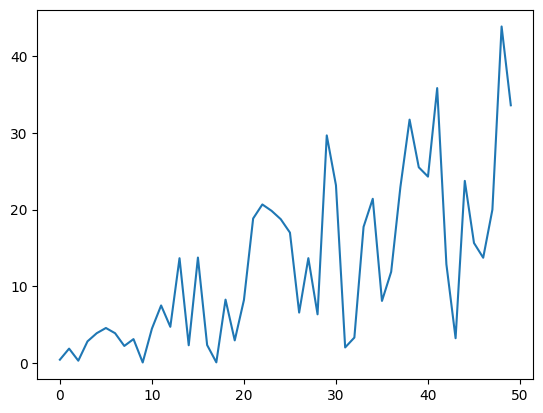

In [2]:
list_a = np.random.rand(50)                                  # 50개의 시계열 데이터 생성 # 난수 데이터 50개 생성

# 추세 추가 # 추세를 보이기 위해서 작성된 것 # 가중치를 점점 크게해서 추세가 증가하는 우상향하는 그래프를 그림
list_a = [(idx+1) * val for idx, val in enumerate(list_a)]   
# 1. enumerate(list_a) : list_a의 값을 하나씩 꺼내어 순서대로 (인덱스, idx)를 부여함

# 시각화
plt.plot(list_a)                                            
plt.show()

# 이제 로그 변환을 적용시켜보자

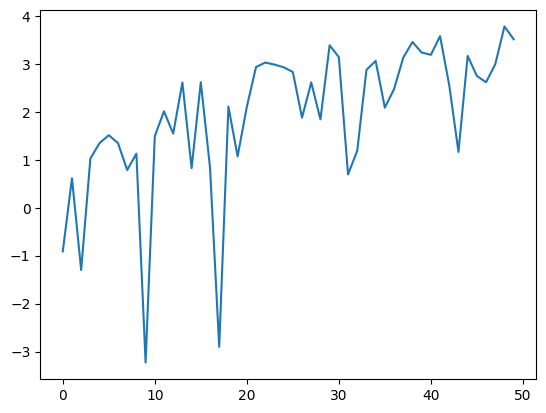

In [3]:
# 로그 변환               # 작읍값은 크게 , 큰 값은 작게
list_a =np.log(list_a)
# np.log(list_a) 를 통해 로그 변환한 값을 다시 list_a 변수에 넣어준다.

plt.plot(list_a)
plt.show()

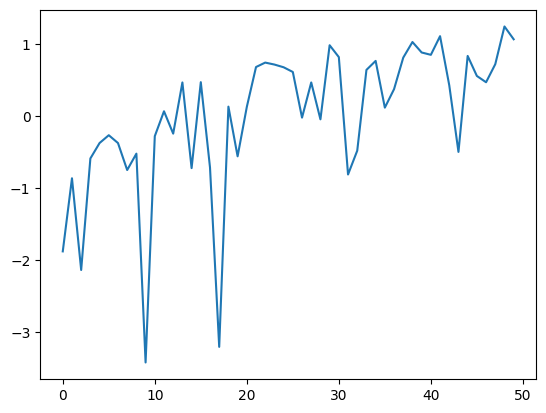

In [4]:
# 로그 변환한 데이터에 스케일러 적용
from sklearn import preprocessing

list_a = preprocessing.scale(list_a)
# Standardization 작업을 함 : 전체 데이터의 중심을 0으로 옮기고 표준편차를 1로 해서 표준화함

plt.plot(list_a)
plt.show()

# 적용해보니 약간 추세가 줄어들어도, 추세의 경향이 남아있으니 차분을 해보자

# 차분

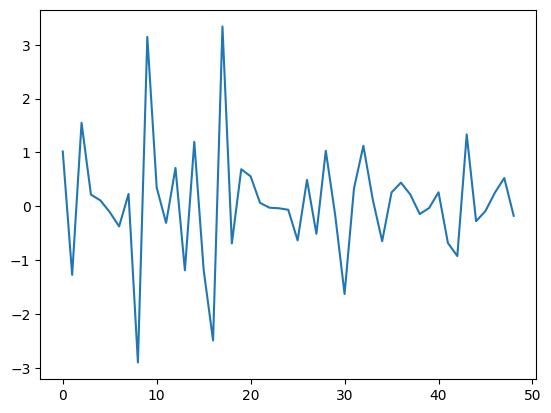

In [5]:
### diff()
# 뎅터의 추세, 계절성 같은 불규칙 요소를 제거하기 위한 전처리 기법


list_a = np.diff(list_a)
# 현재 데이터에서 이전 데이터의 기법을 빼서 변화량만 남기는 방법!

plt.plot(list_a)
plt.show()

In [6]:
# 차분은 어케 동작하노?

import numpy as np

list_a = [1, 2, 3, 4, 5]
print(list_a)
print(np.diff(list_a))

# 결과를 봄ㄴ list_a는 1씩 증가한다 즉, 현재 데이터 - 이전 데이터 = 1 이 된다.
# 차분한 결과를 출력한 결과 모두 1이 나온다.

[1, 2, 3, 4, 5]
[1 1 1 1]


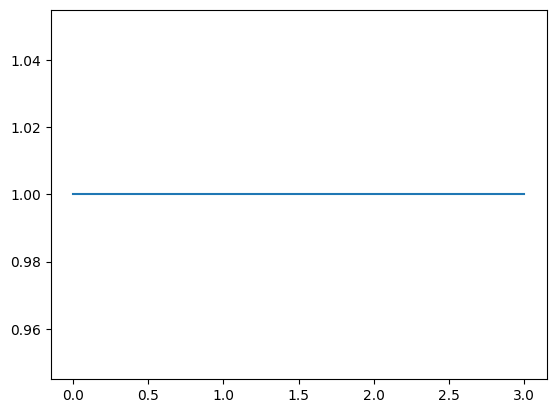

In [7]:
# diff()
# 차분된 결과를 그래프로도 나타낸 것 모두 1이 나왔기에 평탄한 값이 나온다.

list_a = np.diff(list_a)
plt.plot(list_a)
plt.show()

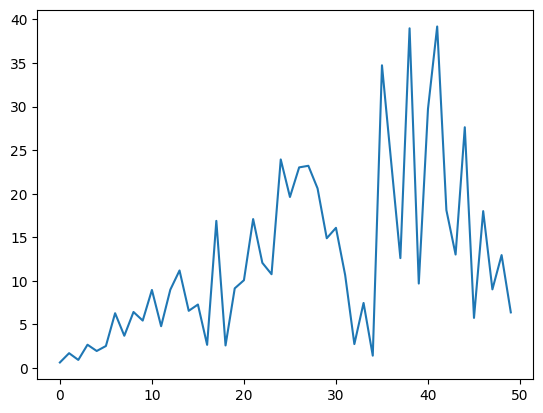

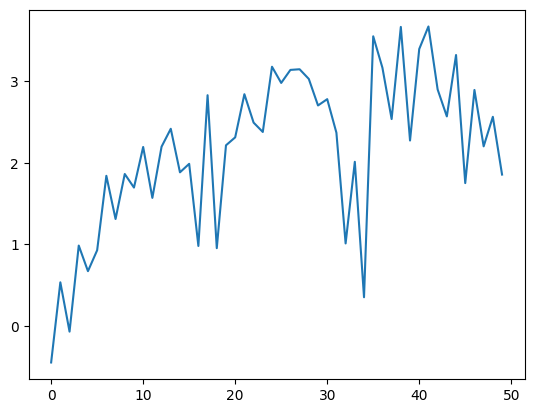

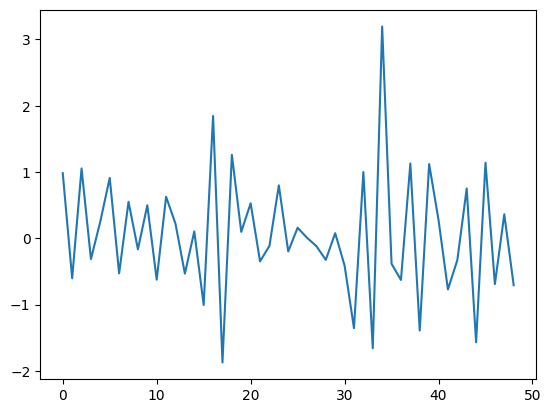

In [8]:
# 3가지 과정을 한꺼번에 확인해보자

## 원본 데이터
list_a = np.random.rand(50)                                  # 50개의 시계열 데이터 생성 # 난수 데이터 50개 생성
list_a = [(idx+1) * val for idx, val in enumerate(list_a)]   # 추세 추가                # 추세를 보이기 위해서 작성된 것
plt.plot(list_a)                                             # 시각화
plt.show()

# 이제 로그 변환을 적용시켜보자

## 로그 변환               # 작읍값은 크게 , 큰 값은 작게
list_a =np.log(list_a)
plt.plot(list_a)
plt.show()

# diff()
## 차분
list_a = np.diff(list_a)
plt.plot(list_a)
plt.show()

# 예제 2

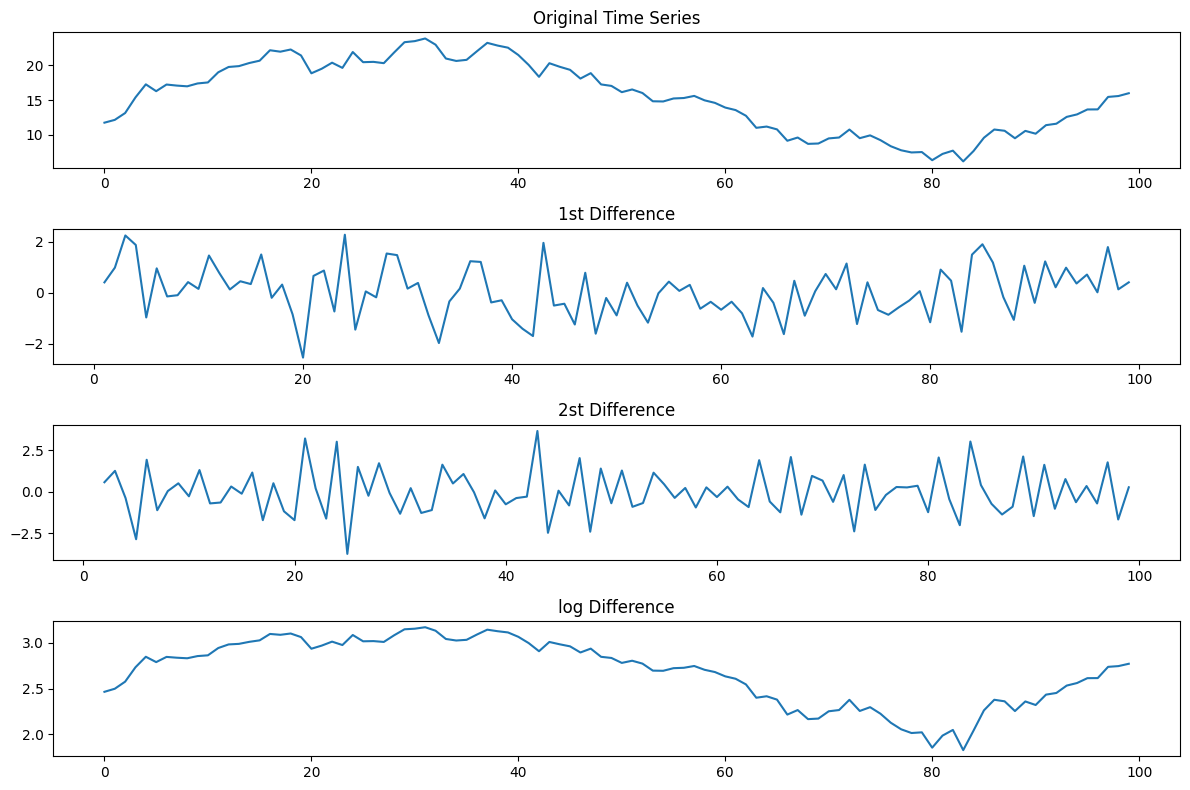

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

 # 데이터 생성
np.random.seed(0)
n = 100
data = np.cumsum(np.random.randn(n)) + 10
time_series = pd.Series(data)

# 1차 차분
diff_1 = time_series.diff()

# 2차 차분
diff_2 = diff_1.diff()

# 로그변환
diff_3 = np.log(time_series)

plt.figure(figsize=(12,8))
plt.subplot(4,1,1)
plt.plot(time_series)
plt.title('Original Time Series')

plt.subplot(4,1,2)
plt.plot(diff_1)
plt.title('1st Difference')

plt.subplot(4,1,3)
plt.plot(diff_2)
plt.title('2st Difference')

plt.subplot(4,1,4)
plt.plot(diff_3)
plt.title('log Difference')

plt.tight_layout()
plt.show()

# 이동평균 평활법

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('daily-total-female-births-CA.csv')
df.head()

,date,births
0,1959-01-01,35
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44


In [12]:
# https://www.kaggle.com/datasets/dougcresswell/daily-total-female-births-in-california-1959

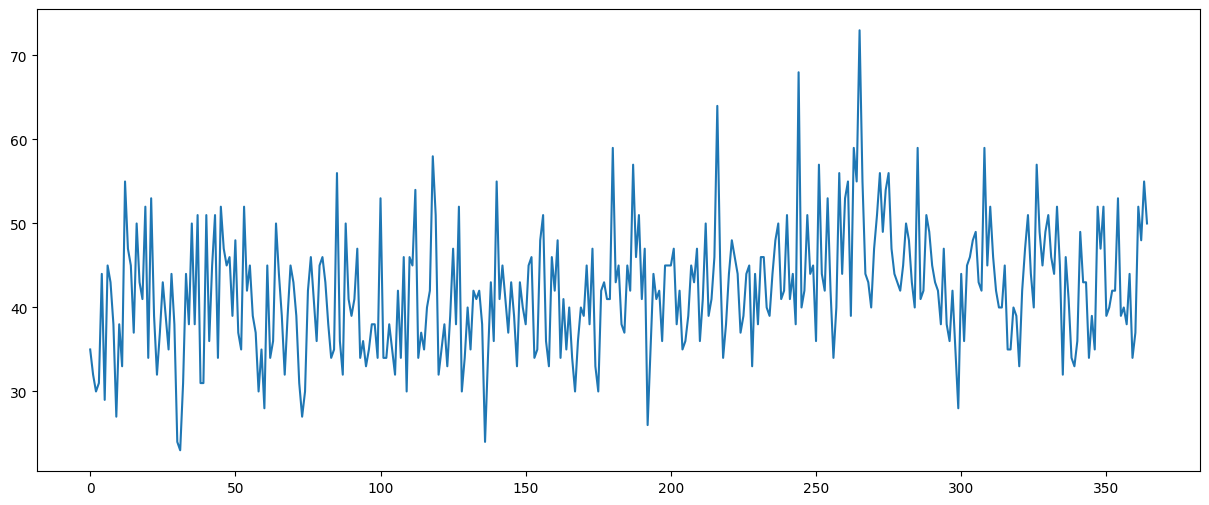

In [13]:
df.births.plot(figsize=(15, 6))
plt.show()

In [14]:
# 이동평균 평활법을 나타낼 수 있는 함수를 한 번 나타내 보쟈

def SMA(array, window):          # 단순 이동 평균
    array = np.array(array)
    assert array.ndim == 1, "1차원 array만 입력할 수 있습니다."
    n = len(array)

    result = np.empty(n)
    result[:] = np.nan

    ma = []
    for i in range(0, n-window+1):
        m = np.mean(array[i:i+window])
        ma.append(m)

    result[window-1:] = ma
    return np.array(result)
        

In [15]:
timestamp = df.births

[ nan  nan  nan  nan 34.4 33.2 35.8 38.4 39.8 36.4 38.2 35.8 38.2 40.
 43.6 43.4 46.8 44.4 43.2 44.6]


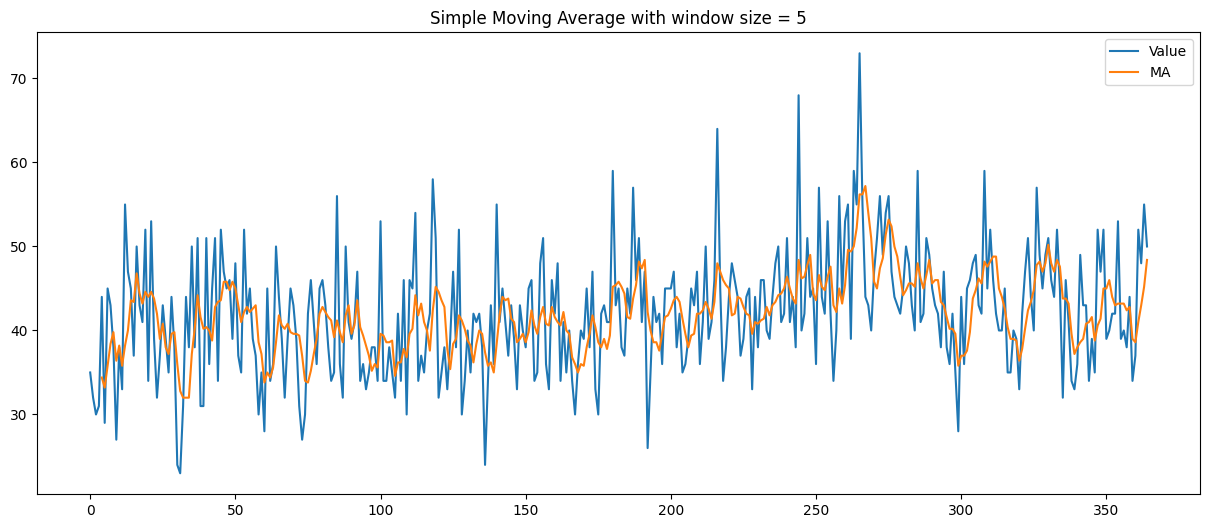

In [16]:
window = 5
sma = SMA(timestamp, window)
print(sma[:20])

timestamp.plot(figsize=(15, 6))
plt.plot(sma)
plt.legend(['Value', 'MA'])
plt.title('Simple Moving Average with window size = {}'.format(window))
plt.show()

[ nan  nan  nan  nan  nan  nan  nan  nan  nan 35.4 35.7 35.8 38.3 39.9
 40.  40.8 41.3 41.3 41.6 44.1]


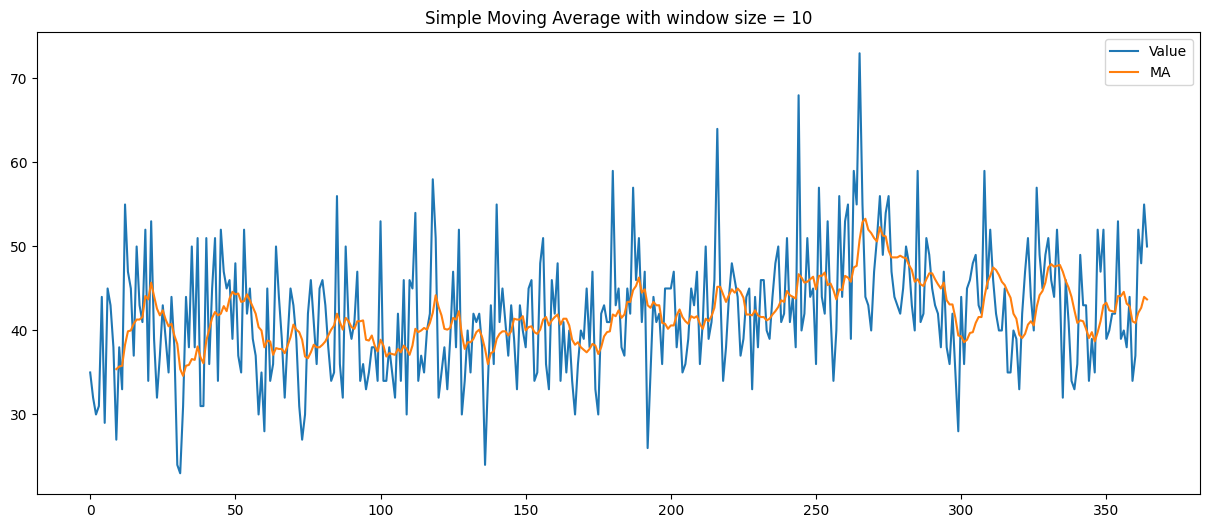

In [17]:
window = 10
sma = SMA(timestamp, window)
print(sma[:20])

timestamp.plot(figsize=(15, 6))
plt.plot(sma)
plt.legend(['Value', 'MA'])
plt.title('Simple Moving Average with window size = {}'.format(window))
plt.show()



[  nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan
   nan   nan   nan   nan   nan   nan   nan 39.75]


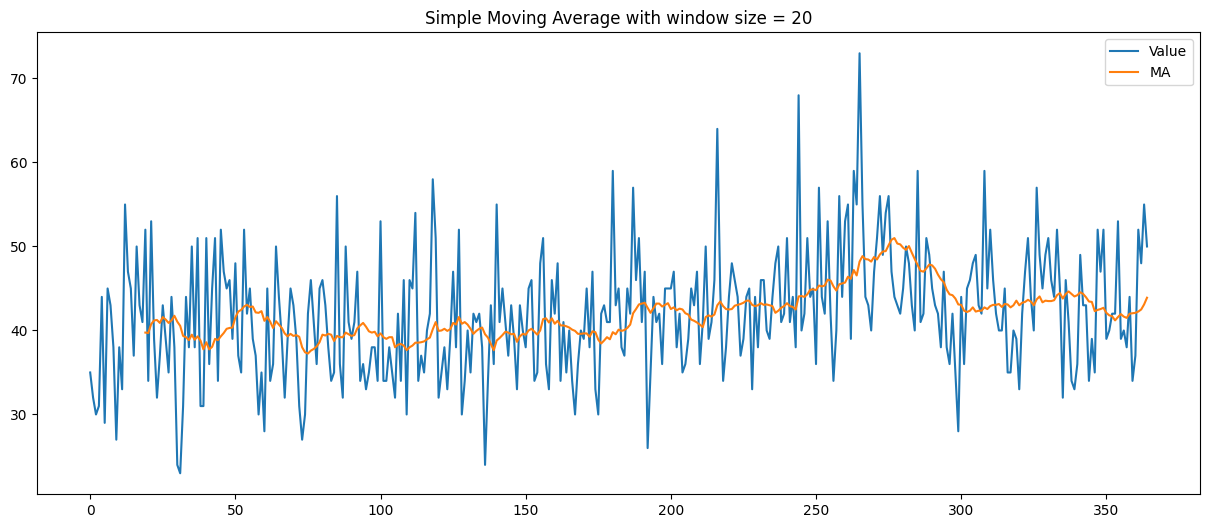

In [18]:
window = 20
sma = SMA(timestamp, window)
print(sma[:20])

timestamp.plot(figsize=(15, 6))
plt.plot(sma)
plt.legend(['Value', 'MA'])
plt.title('Simple Moving Average with window size = {}'.format(window))
plt.show()

In [19]:
# 여기까지가 단순이동평균에 대한 내용이다

### 누적이동평균

In [20]:
def CMA(array): # 누적 이동 평균
    array = np.array(array)
    assert array.ndim == 1, "1차원 array만 입력할 수 있습니다."
    n = len(array)

    result = []
    for i in range(n):
        m = np.mean(array[0:i+1]) # 누적하면 평균을 구하는 부분
        result.append(m)

    return np.array(result)

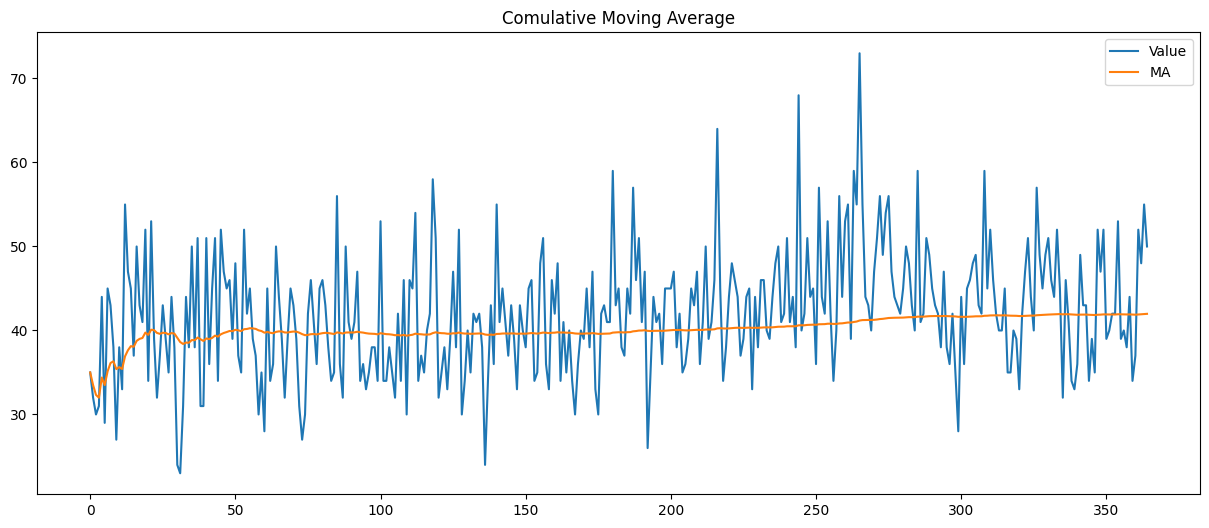

In [21]:
cma = CMA(timestamp)

timestamp.plot(figsize=(15, 6))
plt.plot(cma)
plt.legend(['Value', 'MA'])
plt.title('Comulative Moving Average')
plt.show()

In [22]:

def WMA(array, window):          # 가중 이동 평균
    array = np.array(array)
    assert array.ndim == 1, "1차원 array만 입력할 수 있습니다."
    n = len(array)

    result = np.empty(n)
    result[:] = np.nan

    weight = np.arange(1, window+1, 1) # 가중치 설정
    
    ma = []
    for i in range(0, n-window+1):
        A = np.sum(weight * array[i:i+window])
        B = np.sum(weight)
        m = A / B
        ma.append(m)

    result[window-1:] = ma
    return np.array(result)
        

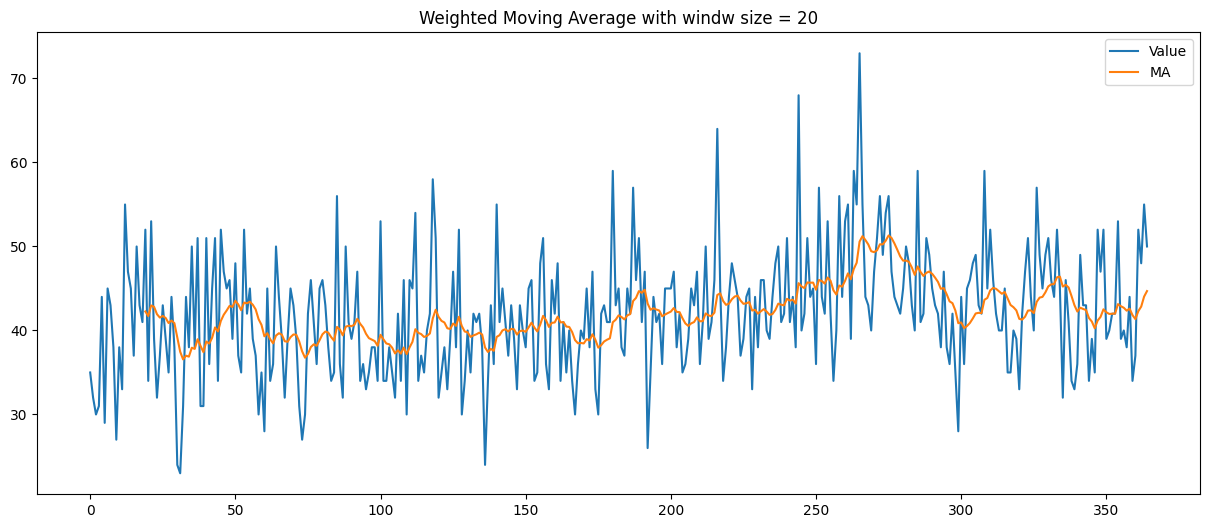

In [23]:
wma = WMA(timestamp,window)

timestamp.plot(figsize=(15, 6))
plt.plot(wma)
plt.legend(['Value', 'MA'])
plt.title('Weighted Moving Average with windw size = {}'.format(window))
plt.show()

### 지수 가중 이동 평균

In [24]:
def EWMA(array, alpha): # 지수 가중 이동 평균 # e : 지수를 의미함 
    array = np.array(array)
    assert array.ndim == 1, "1차원 array만 입력할 수 있습니다."
    n = len(array)

    ma = []
    ma.append(array[0]) # 1번째 지수가중이동평균 = 1번째 데이터 값
    for i in range(1, n):
        # n번째 지수가중이동평균 = a * 현재 데이터값 + (1 - a ) * (n - 1 번째 지수가중평균)
        m = alpha * array[i] + (1-alpha) * ma[-1] # alpha 값에 따라 현재 값의 영향력을 미침 // 알파가커지면 현재값에 영향이 커짐!
        ma.append(m)

    return np.array(ma)

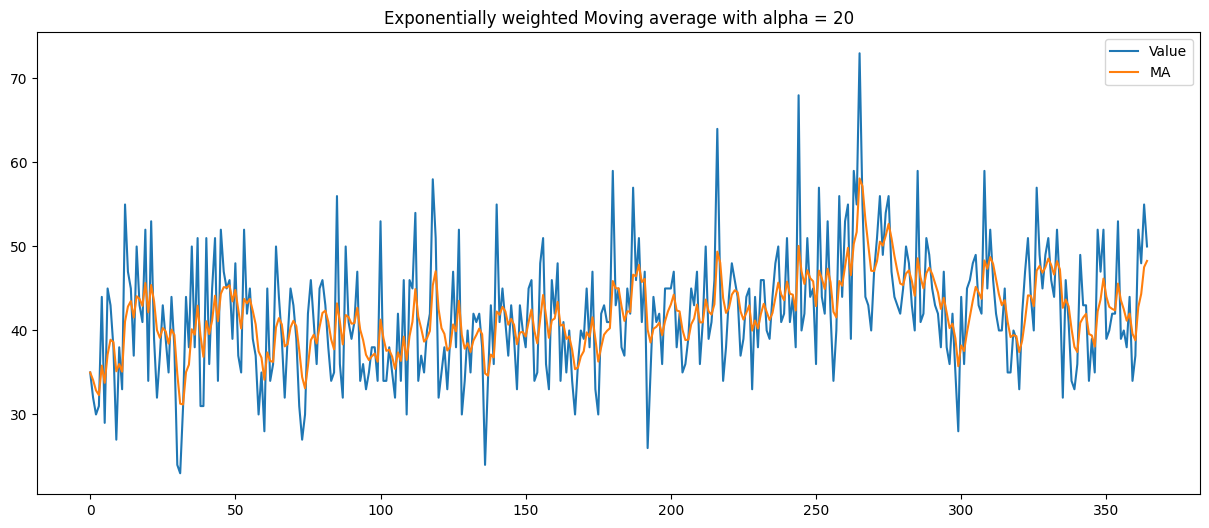

In [25]:
alpha = 0.3

ewma = EWMA(timestamp, alpha)

timestamp.plot(figsize=(15, 6))
plt.plot(ewma)
plt.legend(['Value', 'MA'])
plt.title('Exponentially weighted Moving average with alpha = {}'.format(window))
plt.show()

# pip install yfinance 

In [26]:
# 야후 파이넌스에서 추가 데이터를 가져올 수 있도록 해주는 라이버러리
# 사이트 내의 주가정보를 추출할 수 있도록 해주는 기능!!!
# 이를 사용하는 방법에 대해서 알아보쟈 ㅎㅎ

In [27]:
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date
from statsmodels.tsa.holtwinters import (ExponentialSmoothing,
                                         SimpleExpSmoothing,
                                         Holt)

In [28]:
plt.set_cmap('cubehelix')          # 기본 컬러맵을 cubehelix의 스타일로 지
sns.set_palette('cubehelix')
COLORS = [plt.cm.cubehelix(x) for x in [0.1, 0.3, 0.5, 0.7]]

<Figure size 640x480 with 0 Axes>

In [29]:
# 데이터 로드하는 과정
df = yf.download('AAPL',
               start='2023-01-01',
               end='2023-12-31',
               progress=False)
df.head(2)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2023-01-03,122.982719,128.715417,122.097738,128.105769,112117500
2023-01-04,124.251198,126.512816,122.992561,124.772352,89113600


In [30]:
# 이동평균(moving average)를 구하는 과정이다. 
# rolling(window=5) // 최근 5개의 데이터를 묶어 
# mean() // 그룹으로 묶인 5개의 데이터의 평균값을 구하라는 뜻 
moving_average = df['Close'].rolling(window=5).mean() 
moving_average

# 이거가지고 이제 차트를 그려보자

## Ticker : 주식 종목 코드를 의미한다. // 여기서는 애플(AAPL)을 의미한다.

Ticker,AAPL
2023-01-03,NaN
2023-01-04,NaN
2023-01-05,NaN
2023-01-06,NaN
2023-01-09,125.120435
...,...
2023-12-22,193.003317
2023-12-26,192.441687
2023-12-27,191.692169
2023-12-28,191.444968


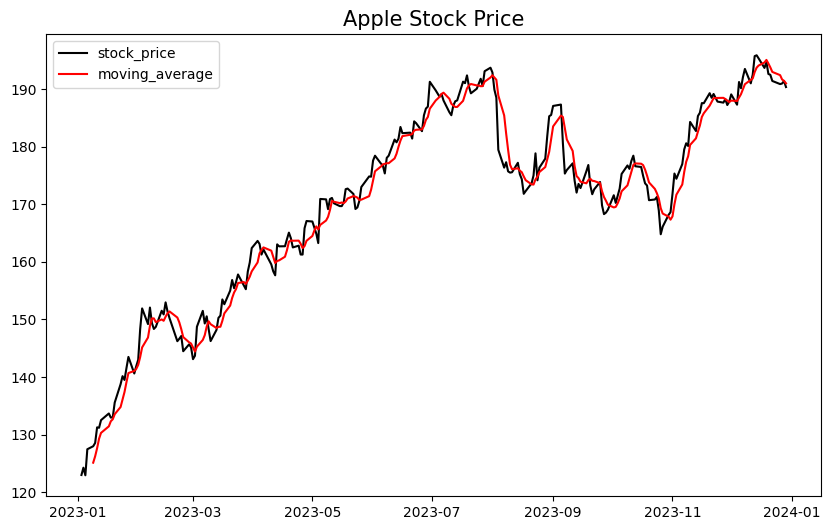

In [31]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (10,6))
fig.set_facecolor('white')
plt.plot(df.index, df.Close, color='k', label='stock_price')
plt.plot(moving_average.index, moving_average, color='red', label='moving_average')
plt.legend()
plt.title('Apple Stock Price', fontsize=15)
plt.show()

In [32]:
# AAPL.CSV 파일 사용해보기
df = pd.read_csv('./AAPL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [33]:
df['Date'] = pd.DatetimeIndex(df['Date'])
df = df.set_index(keys = 'Date')
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [34]:
#               월단위 기준
aapl = df.resample('ME').last().rename(columns = {'Adj Close' : 'adj_close'}).adj_close
aapl.head()

Date
1980-12-31    0.119080
1981-01-31    0.098578
1981-02-28    0.092472
1981-03-31    0.085493
1981-04-30    0.099015
Freq: ME, Name: adj_close, dtype: float64

In [35]:
aapl_indices = aapl.index >= '2015-01-01'
aapl_2015 = aapl[aapl_indices]
aapl_2015.head()

Date
2015-01-31    26.484514
2015-02-28    29.153534
2015-03-31    28.238945
2015-04-30    28.402336
2015-05-31    29.690079
Freq: ME, Name: adj_close, dtype: float64

In [36]:
train_indices = aapl_2015.index < '2022-01-01'
aapl_train = aapl_2015[train_indices]
aapl_test = aapl_2015[~train_indices]

In [37]:
train_length = len(aapl_train)
test_length = len(aapl_test)
print(train_length, test_length)

84 3


In [38]:
ses_1 = SimpleExpSmoothing(aapl_train).fit(smoothing_level=0.2) # 단순지수를 활용한 기법
ses_forecast_1 = ses_1.forecast(test_length)                    # 수동으로 설계하는 기법

ses_2 = SimpleExpSmoothing(aapl_train).fit(smoothing_level=0.5)
ses_forecast_2 = ses_2.forecast(test_length)

ses_3 = SimpleExpSmoothing(aapl_train).fit()
alpha = ses_3.model.params['smoothing_level']                   # 자동으로 설계한느 기법
ses_forecast_3 = ses_3.forecast(test_length)

C:\Project\Project_source\AI01\.venv\Lib\site-packages\pandas\util\_decorators.py:220: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Project\Project_source\AI01\.venv\Lib\site-packages\pandas\util\_decorators.py:220: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


<Axes: title={'center': 'Simple Exponential Smoothing'}, xlabel='Date'>

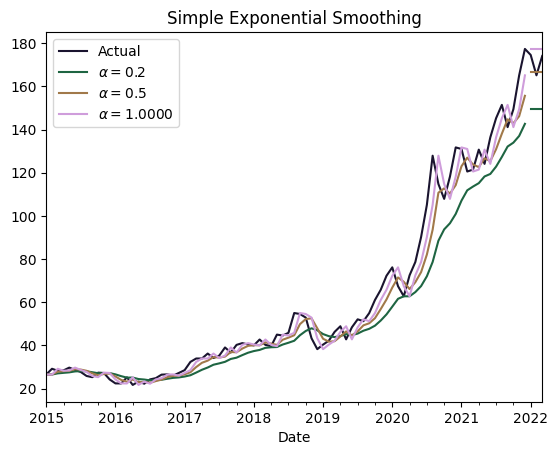

In [39]:
aapl_2015.plot(color=COLORS[0],
               title='Simple Exponential Smoothing',
               label='Actual',
               legend=True)

ses_forecast_1.plot(color=COLORS[1], legend=True, label=r'$\alpha=0.2$')
ses_1.fittedvalues.plot(color=COLORS[1])

ses_forecast_2.plot(color=COLORS[2], legend=True, label=r'$\alpha=0.5$')
ses_2.fittedvalues.plot(color=COLORS[2])

ses_forecast_3.plot(color=COLORS[3], legend=True, label=r'$\alpha={0:.4f}$'.format(alpha))
ses_3.fittedvalues.plot(color=COLORS[3])

In [40]:
import pandas as pd
import numpy as np

data = {'A': [1, 2, np.nan, 4, 5],
        'B': [5, np.nan, np.nan, 8, 9],
        'C': [9, 10, 11, 12, 13]}

df = pd.DataFrame(data)
df

,A,B,C
0,1.0,5.0,9
1,2.0,NaN,10
2,NaN,NaN,11
3,4.0,8.0,12
4,5.0,9.0,13


In [41]:
df_interpolated = df.interpolate() # method = 'linear'가 기본값임
df_interpolated

,A,B,C
0,1.0,5.0,9
1,2.0,6.0,10
2,3.0,7.0,11
3,4.0,8.0,12
4,5.0,9.0,13


In [42]:
df_interpolated2 = df['A'].interpolate()
print(df_interpolated2)

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
Name: A, dtype: float64


In [43]:
df_interpolated = df.interpolate(method='polynomial', order=1)
print(df_interpolated)

     A    B   C
0  1.0  5.0   9
1  2.0  6.0  10
2  3.0  7.0  11
3  4.0  8.0  12
4  5.0  9.0  13


In [44]:
df_interpolated2 = df['A'].interpolate(method='spline', order=3)
df_interpolated2

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
Name: A, dtype: float64

In [45]:
import pprint
import yfinance as yf

ticker = yf.Ticker('AAPL')
pprint.pprint(ticker.info)

{'52WeekChange': 0.54248035,
 'SandP52WeekChange': 0.26208222,
 'address1': 'One Apple Park Way',
 'allTimeHigh': 311.4,
 'allTimeLow': 0.049107,
 'ask': 309.89,
 'askSize': 5,
 'auditRisk': 2,
 'averageAnalystRating': '2.0 - Buy',
 'averageDailyVolume10Day': 43241680,
 'averageDailyVolume3Month': 43882808,
 'averageVolume': 43882808,
 'averageVolume10days': 43241680,
 'beta': 1.065,
 'bid': 308.55,
 'bidSize': 5,
 'boardRisk': 1,
 'bookValue': 7.26,
 'city': 'Cupertino',
 'companyOfficers': [{'age': 64,
                      'exercisedValue': 0,
                      'fiscalYear': 2025,
                      'maxAge': 1,
                      'name': 'Mr. Timothy D. Cook',
                      'title': 'CEO & Director',
                      'totalPay': 16759518,
                      'unexercisedValue': 0,
                      'yearBorn': 1961},
                     {'age': 53,
                      'exercisedValue': 0,
                      'fiscalYear': 2025,
                    

In [46]:
# Period : ['1d', '5d', '1mo', '3mo', '6mo', '1y', '2y', '5y', '10y', 'ytd', 'max']
print(ticker.history(period='5d'))

                                 Open        High         Low       Close  \
Date                                                                        
2026-05-18 00:00:00-04:00  300.239990  300.660004  294.910004  297.839996   
2026-05-19 00:00:00-04:00  296.970001  300.510010  296.350006  298.970001   
2026-05-20 00:00:00-04:00  298.179993  302.799988  298.079987  302.250000   
2026-05-21 00:00:00-04:00  301.059998  305.540009  300.399994  304.989990   
2026-05-22 00:00:00-04:00  306.119995  311.399994  305.839996  308.820007   

                             Volume  Dividends  Stock Splits  
Date                                                          
2026-05-18 00:00:00-04:00  34483000        0.0           0.0  
2026-05-19 00:00:00-04:00  42243600        0.0           0.0  
2026-05-20 00:00:00-04:00  38229800        0.0           0.0  
2026-05-21 00:00:00-04:00  42965100        0.0           0.0  
2026-05-22 00:00:00-04:00  43627900        0.0           0.0  


In [47]:
print(ticker.income_stmt)

                                                      2025-09-30  \
Tax Effect Of Unusual Items                         0.000000e+00   
Tax Rate For Calcs                                  1.560000e-01   
Normalized EBITDA                                   1.447480e+11   
Net Income From Continuing Operation Net Minori...  1.120100e+11   
Reconciled Depreciation                             1.169800e+10   
Reconciled Cost Of Revenue                          2.209600e+11   
EBITDA                                              1.447480e+11   
EBIT                                                1.330500e+11   
Net Interest Income                                          NaN   
Interest Expense                                             NaN   
Interest Income                                              NaN   
Normalized Income                                   1.120100e+11   
Net Income From Continuing And Discontinued Ope...  1.120100e+11   
Total Expenses                                  

In [48]:
print(ticker.recommendations)

  period  strongBuy  buy  hold  sell  strongSell
0     0m          7   23    16     1           1
1    -1m          7   25    14     1           1
2    -2m          6   25    15     1           1
3    -3m          5   25    16     1           1


In [49]:
ticker = yf.Ticker('SNDK')

In [50]:
ticker.recommendations

,period,strongBuy,buy,hold,sell,strongSell
0,0m,2,15,4,0,1
1,-1m,2,14,4,0,1
2,-2m,2,12,6,0,0
3,-3m,2,12,6,0,0


# prophet

In [51]:
# https://facebook.github.io/prophet/

In [52]:
from prophet import Prophet   # pip install Prophet
import pandas as pd

Importing plotly failed. Interactive plots will not work.


17:46:37 - cmdstanpy - INFO - Chain [1] start processing
17:46:37 - cmdstanpy - INFO - Chain [1] done processing


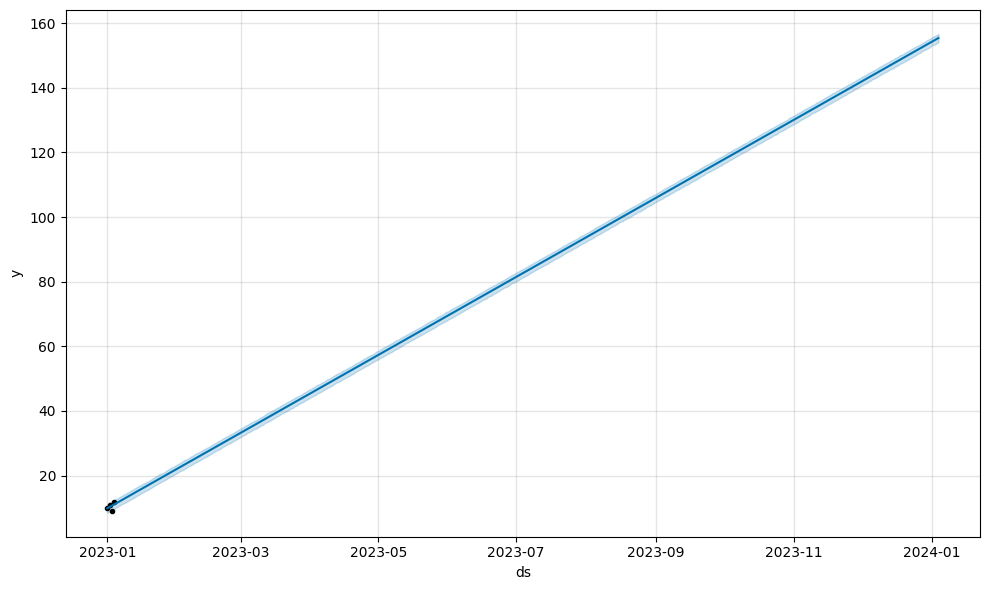

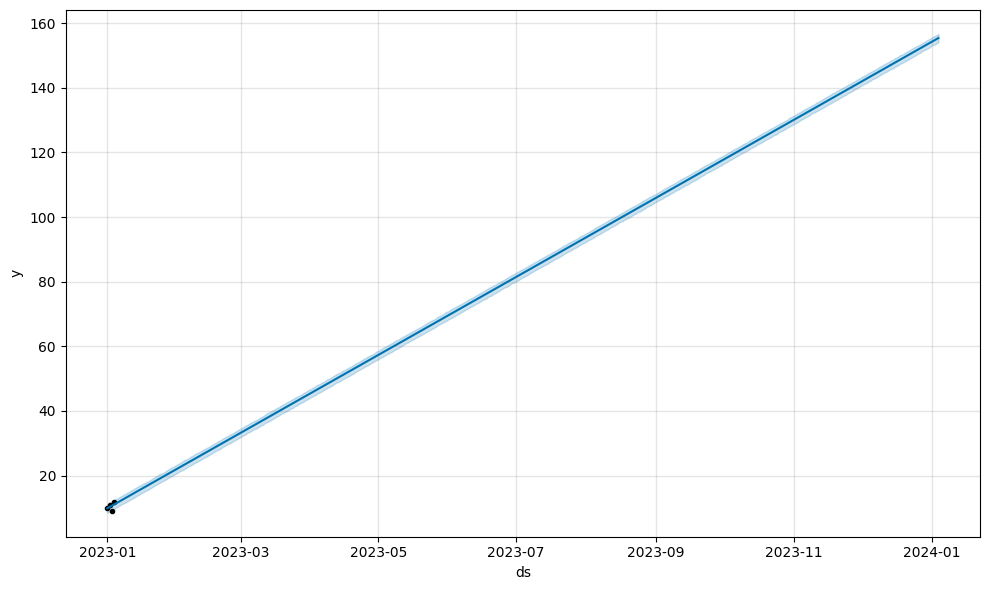

In [53]:
df = pd.DataFrame({
    'ds': ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04'], # 반드시 사용해야할 변수 : df : 시계열 데이터의 날짜 나타내는 변수
    'y': [10, 11, 9, 12]                                            # 반드시 사용해야할 변수 : y : 실제로 사용할 데이터 
})
df['ds'] = pd.to_datetime(df['ds'])                                 

model = Prophet()
model.fit(df)

future = model.make_future_dataframe(periods=365)                   # 앞으로 예측하고자 하는 데이터 프레임
forecast = model.predict(future)
model.plot(forecast)                                                # 시각화하기 위한 함수

### Prophet에서 사용하는 주요 메소드들
- fit(df)
    - Prophet 모델에 데이터를 적합시키는 메소드다. df는 예측할 시계열 데이터로, ds(날짜)와 y(값)를 포함하는 데이터프레임이다.
- predict(future)
    - 주어진 미래 데이터를 기반으로 예측을 수행하는 메소드다. future는 예측할 기간에 대한 날짜 정보를 포함하는 데이터프레임으로, Prophet은 이를 사용해 미래의 값을 예측한다.
- make_future_dataframe(periods=n)
    - 미래 예측을 위한 날짜 데이터프레임을 생성한다. n은 예측할 기간의 길이를 나타내며, 예측하고자 하는 날짜 범위에 해당한다.
- add_seasonality(name, period, fourier_order)
    - 사용자 정의 계절성을 추가하는 메소드입니다. name은 계절성의 이름, period는 계절성의 주기(예: 365.25), fourier_order는 푸리에 급수의 차수를 지정한다. 이를 통해 기본 제공되는 연간, 주간 계절성 외에 추가적인 주기 패턴을 모델에 반영할 수 있다.
- plot(fcst)
    - Prophet 모델의 예측 결과를 시각화하는 메소드다. 예측된 값(fcst)을 시각적으로 표현하며, 추세, 계절성, 변화점 등을 직관적으로 확인할 수 있다.
- plot_components(fcst)
    - Prophet 모델의 각 성분(추세, 계절성, 휴일 효과 등)을 분해하여 시각화하는 메소드다. 이 메소드를 통해 각 성분이 시계열에 어떻게 기여하는지 확인할 수 있다.

In [54]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'multiplicative_terms', 'multiplicative_terms_lower',
       'multiplicative_terms_upper', 'yhat'],
      dtype='str')

- ds : 날짜 및 시간 정보를 나타내는 열입니다.
- trend : 전반적인 추세를 나타내는 열로, 시간에 따른 데이터의 일반적인 증감 추이를 나타냅니다.
- yhat : 전체 예측 최종값입니다.
- yhat_lower : 예측 값의 최소 하한선(lower bound)을 나타내는 열입니다.
- yhat_upper : 예측 값의 최대 상한선(upper bound)을 나타내는 열입니다.
- trend_lower, trend_upper : 추세의 최소 및 최대 경계를 나타내는 열입니다.
- additive_terms : 일일, 주간, 연간 등의 추가적인 성분을 나타내는 열입니다.
- additive_terms_lower, additive_terms_upper : 추가적인 성분의 최소 및 최대 경계를 나타내는 열입니다.
- daily, daily_lower, daily_upper: 일일 성분에 대한 값과 그 최소 및 최대 경계를 나타내는 열입니다.
- weekly, weekly_lower, weekly_upper: 주간 성분에 대한 값과 그 최소 및 최대 경계를 나타내는 열입니다.
- yearly, yearly_lower, yearly_upper: 연간 성분에 대한 값과 그 최소 및 최대 경계를 나타내는 열입니다.
- multiplicative_terms, multiplicative_terms_lower, multiplicative_terms_upper : 곱셈 항(multiplicative term)에 대한 값과 그 최소 및 최대 경계를 나타내는 열입니다.

# 실전 예제 APPLE 데이터

In [55]:
import pandas as pd

df = pd.read_csv('./AAPL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [56]:
df['ds'] = df['Date']
df['y'] = df['Close']

In [57]:
data = df[['ds', 'y']]
data = data[-1000:]
data.head()

,ds,y
9409,2018-04-06,42.095001
9410,2018-04-09,42.512501
9411,2018-04-10,43.312500
9412,2018-04-11,43.110001
9413,2018-04-12,43.535000


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10409 entries, 0 to 10408
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10409 non-null  str    
 1   Open       10409 non-null  float64
 2   High       10409 non-null  float64
 3   Low        10409 non-null  float64
 4   Close      10409 non-null  float64
 5   Adj Close  10409 non-null  float64
 6   Volume     10409 non-null  int64  
 7   ds         10409 non-null  str    
 8   y          10409 non-null  float64
dtypes: float64(6), int64(1), str(2)
memory usage: 732.0 KB


In [59]:
from prophet import Prophet

prophet_m = Prophet().fit(data)

17:46:38 - cmdstanpy - INFO - Chain [1] start processing
17:46:38 - cmdstanpy - INFO - Chain [1] done processing


In [60]:
future = prophet_m.make_future_dataframe(periods=365)

In [61]:
future.head()

,ds
0,2018-04-06
1,2018-04-09
2,2018-04-10
3,2018-04-11
4,2018-04-12


In [62]:
future.tail()

,ds
1360,2023-03-20
1361,2023-03-21
1362,2023-03-22
1363,2023-03-23
1364,2023-03-24


In [63]:
forecast = prophet_m.predict(future)

In [64]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1360,2023-03-20,203.237317,153.904220,247.269329
1361,2023-03-21,203.600861,152.891971,249.144438
1362,2023-03-22,203.832267,155.398975,249.116309
1363,2023-03-23,203.787032,155.163679,247.383317
1364,2023-03-24,203.702976,155.932455,249.648583


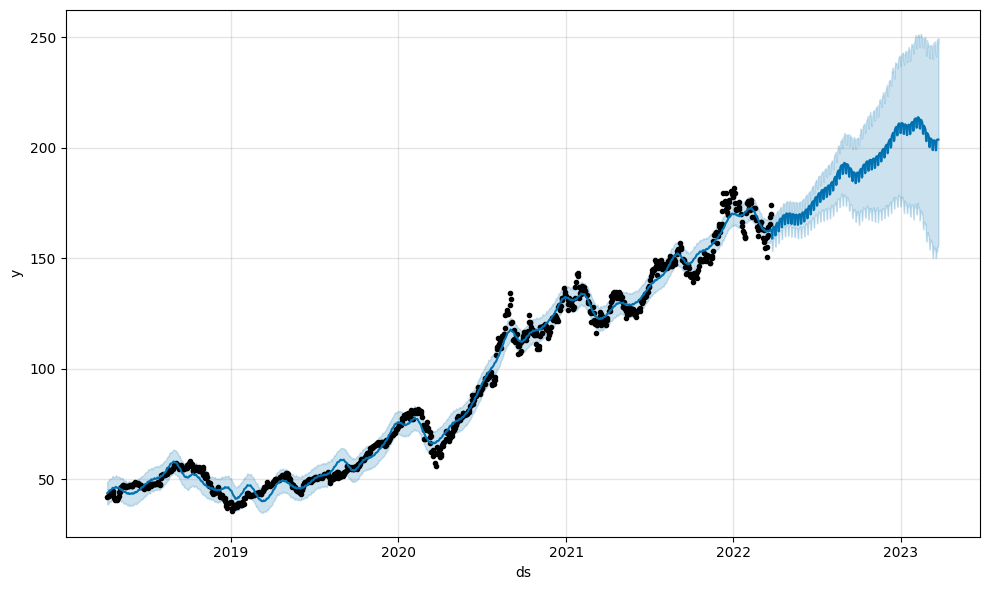

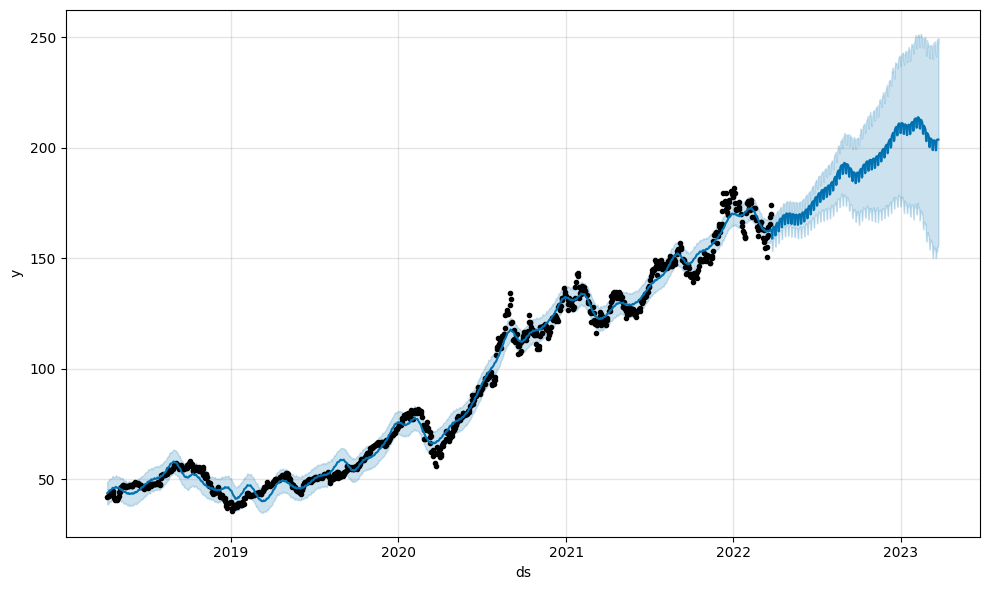

In [65]:
prophet_m.plot(forecast)

# 자동차 판매량 데이터

In [66]:
import pandas as pd

path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
df = pd.read_csv(path, header=0)
df.head()

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Month   108 non-null    str  
 1   Sales   108 non-null    int64
dtypes: int64(1), str(1)
memory usage: 1.8 KB


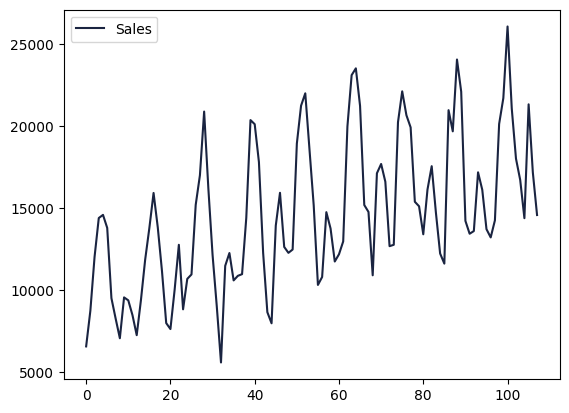

In [68]:
from matplotlib import pyplot

df.plot()
pyplot.show()

In [69]:
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])
df.head()

,ds,y
0,1960-01-01,6550
1,1960-02-01,8728
2,1960-03-01,12026
3,1960-04-01,14395
4,1960-05-01,14587


In [70]:
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])
df.tail()

,ds,y
103,1968-08-01,16722
104,1968-09-01,14385
105,1968-10-01,21342
106,1968-11-01,17180
107,1968-12-01,14577


In [71]:
# 모델만들어서 학습
from prophet import Prophet

model = Prophet()
model.fit(df)

17:46:39 - cmdstanpy - INFO - Chain [1] start processing
17:46:40 - cmdstanpy - INFO - Chain [1] done processing


### In sample Forecast

In [72]:
last_1year = list()
for i in range(1, 13):                                     # 1부터 13까지니깐 12개월을 의미함
    last_1year.append(['1968-%02d' % i])
last_1year = pd.DataFrame(last_1year, columns = ['ds'])
last_1year['ds'] = pd.to_datetime(last_1year['ds'])
last_1year

,ds
0,1968-01-01
1,1968-02-01
2,1968-03-01
3,1968-04-01
4,1968-05-01
5,1968-06-01
6,1968-07-01
7,1968-08-01
8,1968-09-01
9,1968-10-01


In [73]:
forecast = model.predict(last_1year)

In [74]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='str')

In [75]:
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

          ds          yhat    yhat_lower    yhat_upper
0 1968-01-01  14365.818264  12839.141859  15980.431822
1 1968-02-01  14940.296788  13378.136205  16582.202940
2 1968-03-01  20882.023591  19365.680953  22368.578994
3 1968-04-01  22900.422751  21396.990113  24498.074449
4 1968-05-01  24201.075774  22687.656262  25701.829818


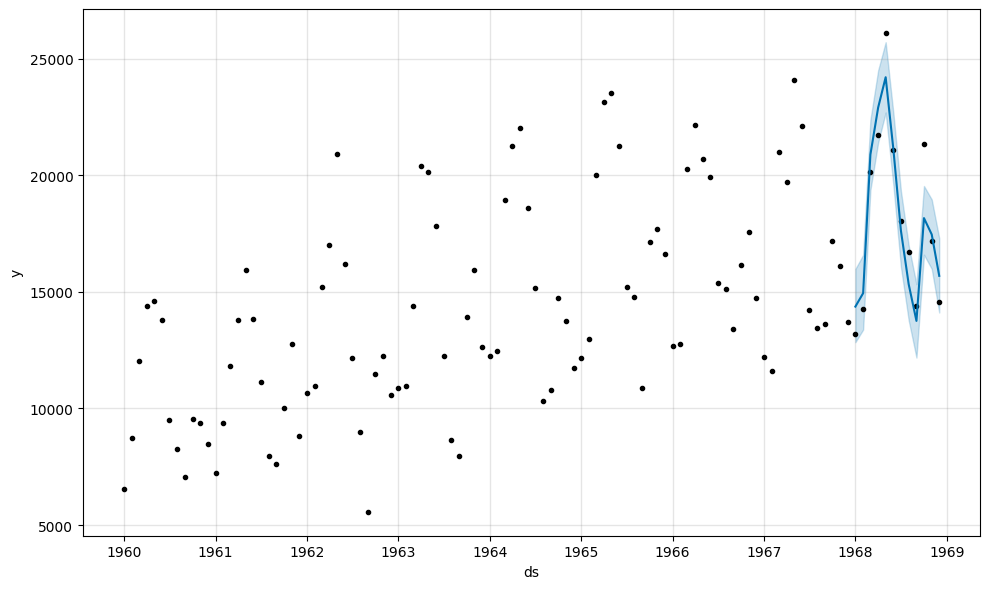

In [76]:
model.plot(forecast)
pyplot.show()

### Out Of Sample Forecast

In [77]:
# 없는 미래를 예측하는 것

In [78]:
last_1year = list()
for i in range(1, 13):
    last_1year.append(['1969-%02d' % i])
last_1year = pd.DataFrame(last_1year, columns = ['ds'])
last_1year['ds'] = pd.to_datetime(last_1year['ds'])
last_1year.head()

,ds
0,1969-01-01
1,1969-02-01
2,1969-03-01
3,1969-04-01
4,1969-05-01


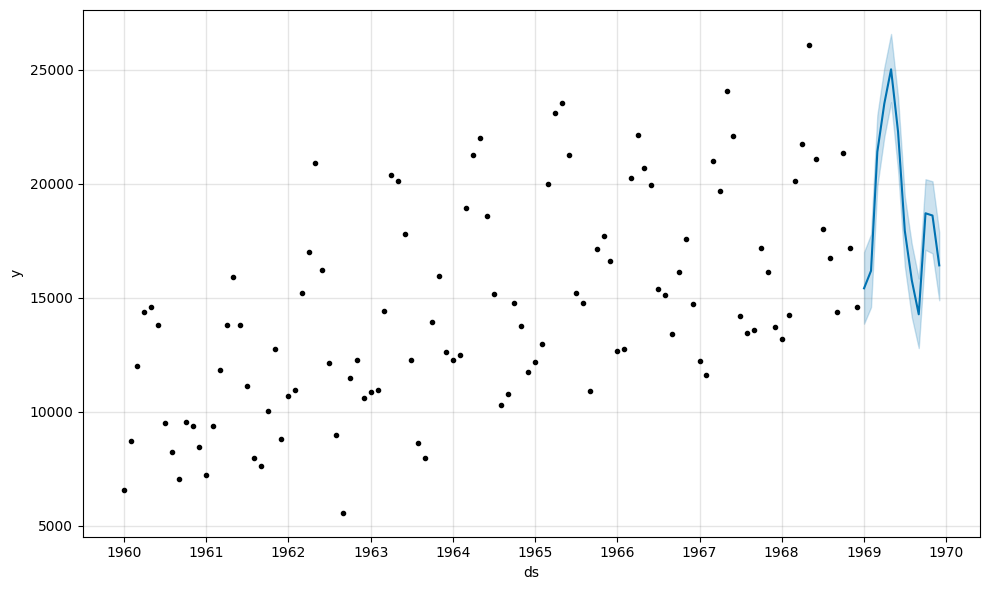

In [79]:
forecast = model.predict(last_1year)
model.plot(forecast)
pyplot.show()

### 모델 평가

In [80]:
train = df.drop(df.index[-12:]) # 마지막 1년치를 제거하는것
y_true = df['y'][-12:].values     

In [81]:
model = Prophet() # 모델을 생성하고
model.fit(train)  # 학습한다.

17:46:40 - cmdstanpy - INFO - Chain [1] start processing
17:46:41 - cmdstanpy - INFO - Chain [1] done processing


In [82]:
last_1year = list()
for i in range(1, 13):
    last_1year.append(['1968-%02d' % i])
last_1year = pd.DataFrame(last_1year, columns = ['ds'])
last_1year['ds'] = pd.to_datetime(last_1year['ds'])
last_1year.head()

,ds
0,1968-01-01
1,1968-02-01
2,1968-03-01
3,1968-04-01
4,1968-05-01


In [83]:
forecast = model.predict(last_1year)
y_pred = forecast['yhat'].values

In [84]:
from sklearn.metrics import mean_absolute_error

# MAE : 절대 평균 오차(mean absolute error) : (1/n)|실제값 - 예측값|
mae = mean_absolute_error(y_true, y_pred)
print('MAE: %.3f' % mae)

MAE: 1336.814


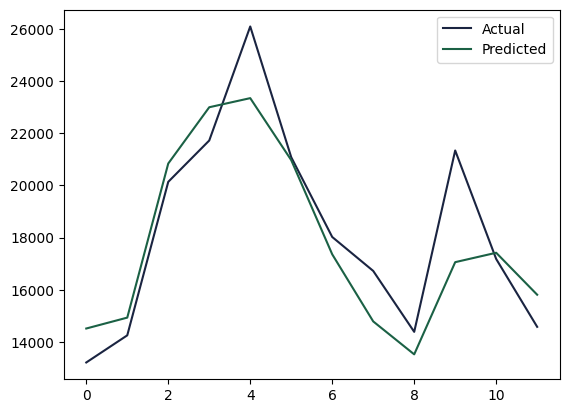

In [85]:
# 시각화시켜보자

pyplot.plot(y_true, label='Actual')
pyplot.plot(y_pred, label='Predicted')
pyplot.legend()
pyplot.show()